# __<u>Import Libraries</u>__

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))   # add the IGPS project root to the path

import importlib
import Library.dataProcessing
# importlib.reload(Library.dataProcessing)

# __<u>Data Directory</u>__

> Import Directory

In [2]:
impDataDir = '../Export/Data/'

> Export Directory

In [3]:
Site_Info   = 'Site-02'
expDataDir  = '../Export/Data/' + Site_Info + '/' 
expModelDir = '../Export/Model/' + Site_Info + '/'
expFigDir   = '../Export/Figure/' + Site_Info + '/'

> Verify Export Directories

In [4]:
import os

# create expDataDir if it doesn't exist
if not os.path.exists(expDataDir):
    os.makedirs(expDataDir)
    print(f"System has created \"{expDataDir}\" directory.")
else:
    print(f"The directory \"{expDataDir}\" already exists.")

# create expModelDir if it doesn't exist
if not os.path.exists(expModelDir):
    os.makedirs(expModelDir)
    print(f"System has created \"{expModelDir}\" directory.")
else:
    print(f"The directory \"{expModelDir}\" already exists.")

# create expFigDir if it doesn't exist
if not os.path.exists(expFigDir):
    os.makedirs(expFigDir)
    print(f"System has created \"{expFigDir}\" directory.")
else:
    print(f"The directory \"{expFigDir}\" already exists.")

The directory "../Export/Data/Site-02/" already exists.
The directory "../Export/Model/Site-02/" already exists.
The directory "../Export/Figure/Site-02/" already exists.


> Define colunmns and rows of pandas output

In [5]:
import pandas as pd
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 30)

# __<u>Dataset Preparing for Model Development and Testing</u>__

> __<u> Load Pre-processed PV Power Plant data</u>__
>> Note: 
>>   * Location : __Gyeongju-si, Gyeongsangbuk-do__
>>   * PV Power Data : C_pcode __71780001, 71780003, 71780004__
>>   * Weather Data : C_scode: __717804001__

In [6]:
Site_02_raw = pd.read_csv(f"{impDataDir}Site#02_Data.gzip", compression="gzip")
Site_02_raw.columns.tolist()

['timestamp',
 'PV1_P_pv',
 'PV1_V_dc',
 'PV1_V_i',
 'PV1_P_dc',
 'PV1_PF',
 'PV1_Freq',
 'PV2_P_pv',
 'PV2_V_dc',
 'PV2_V_i',
 'PV2_P_dc',
 'PV2_PF',
 'PV2_Freq',
 'PV3_P_pv',
 'PV3_V_dc',
 'PV3_V_i',
 'PV3_P_dc',
 'PV3_PF',
 'PV3_Freq',
 'T_env_C',
 'H_env_%',
 'V_wind_m/s',
 'P_rain_mm/h',
 'D_env_g/m^3',
 'P_atm_hPa']

In [7]:
rename_columns = {
    'timestamp'    : 'DT',
    'PV1_P_pv'     : 'P_PV1_kW',
    'PV2_P_pv'     : 'P_PV2_kW',
    'PV3_P_pv'     : 'P_PV3_kW',
}
Site_02 = Site_02_raw.rename(columns=rename_columns)
Select_Columns = ['DT', 'P_PV1_kW', 'P_PV2_kW', 'P_PV3_kW', 'T_env_C', 'H_env_%', 'V_wind_m/s', 'P_rain_mm/h', 'D_env_g/m^3', 'P_atm_hPa']
Site_02 = Site_02[Select_Columns]
Site_02.columns.tolist()

['DT',
 'P_PV1_kW',
 'P_PV2_kW',
 'P_PV3_kW',
 'T_env_C',
 'H_env_%',
 'V_wind_m/s',
 'P_rain_mm/h',
 'D_env_g/m^3',
 'P_atm_hPa']

[despike] V_wind_m/s: removed 3 isolated spike(s); max 55.92 -> 4.54
[despike] P_rain_mm/h: removed 50 isolated spike(s); max 21.85 -> 13.87
Saved: ../Export/Figure/Site-02/diurnal_patterns.pdf
Saved: ../Export/Figure/Site-02/diurnal_patterns.png


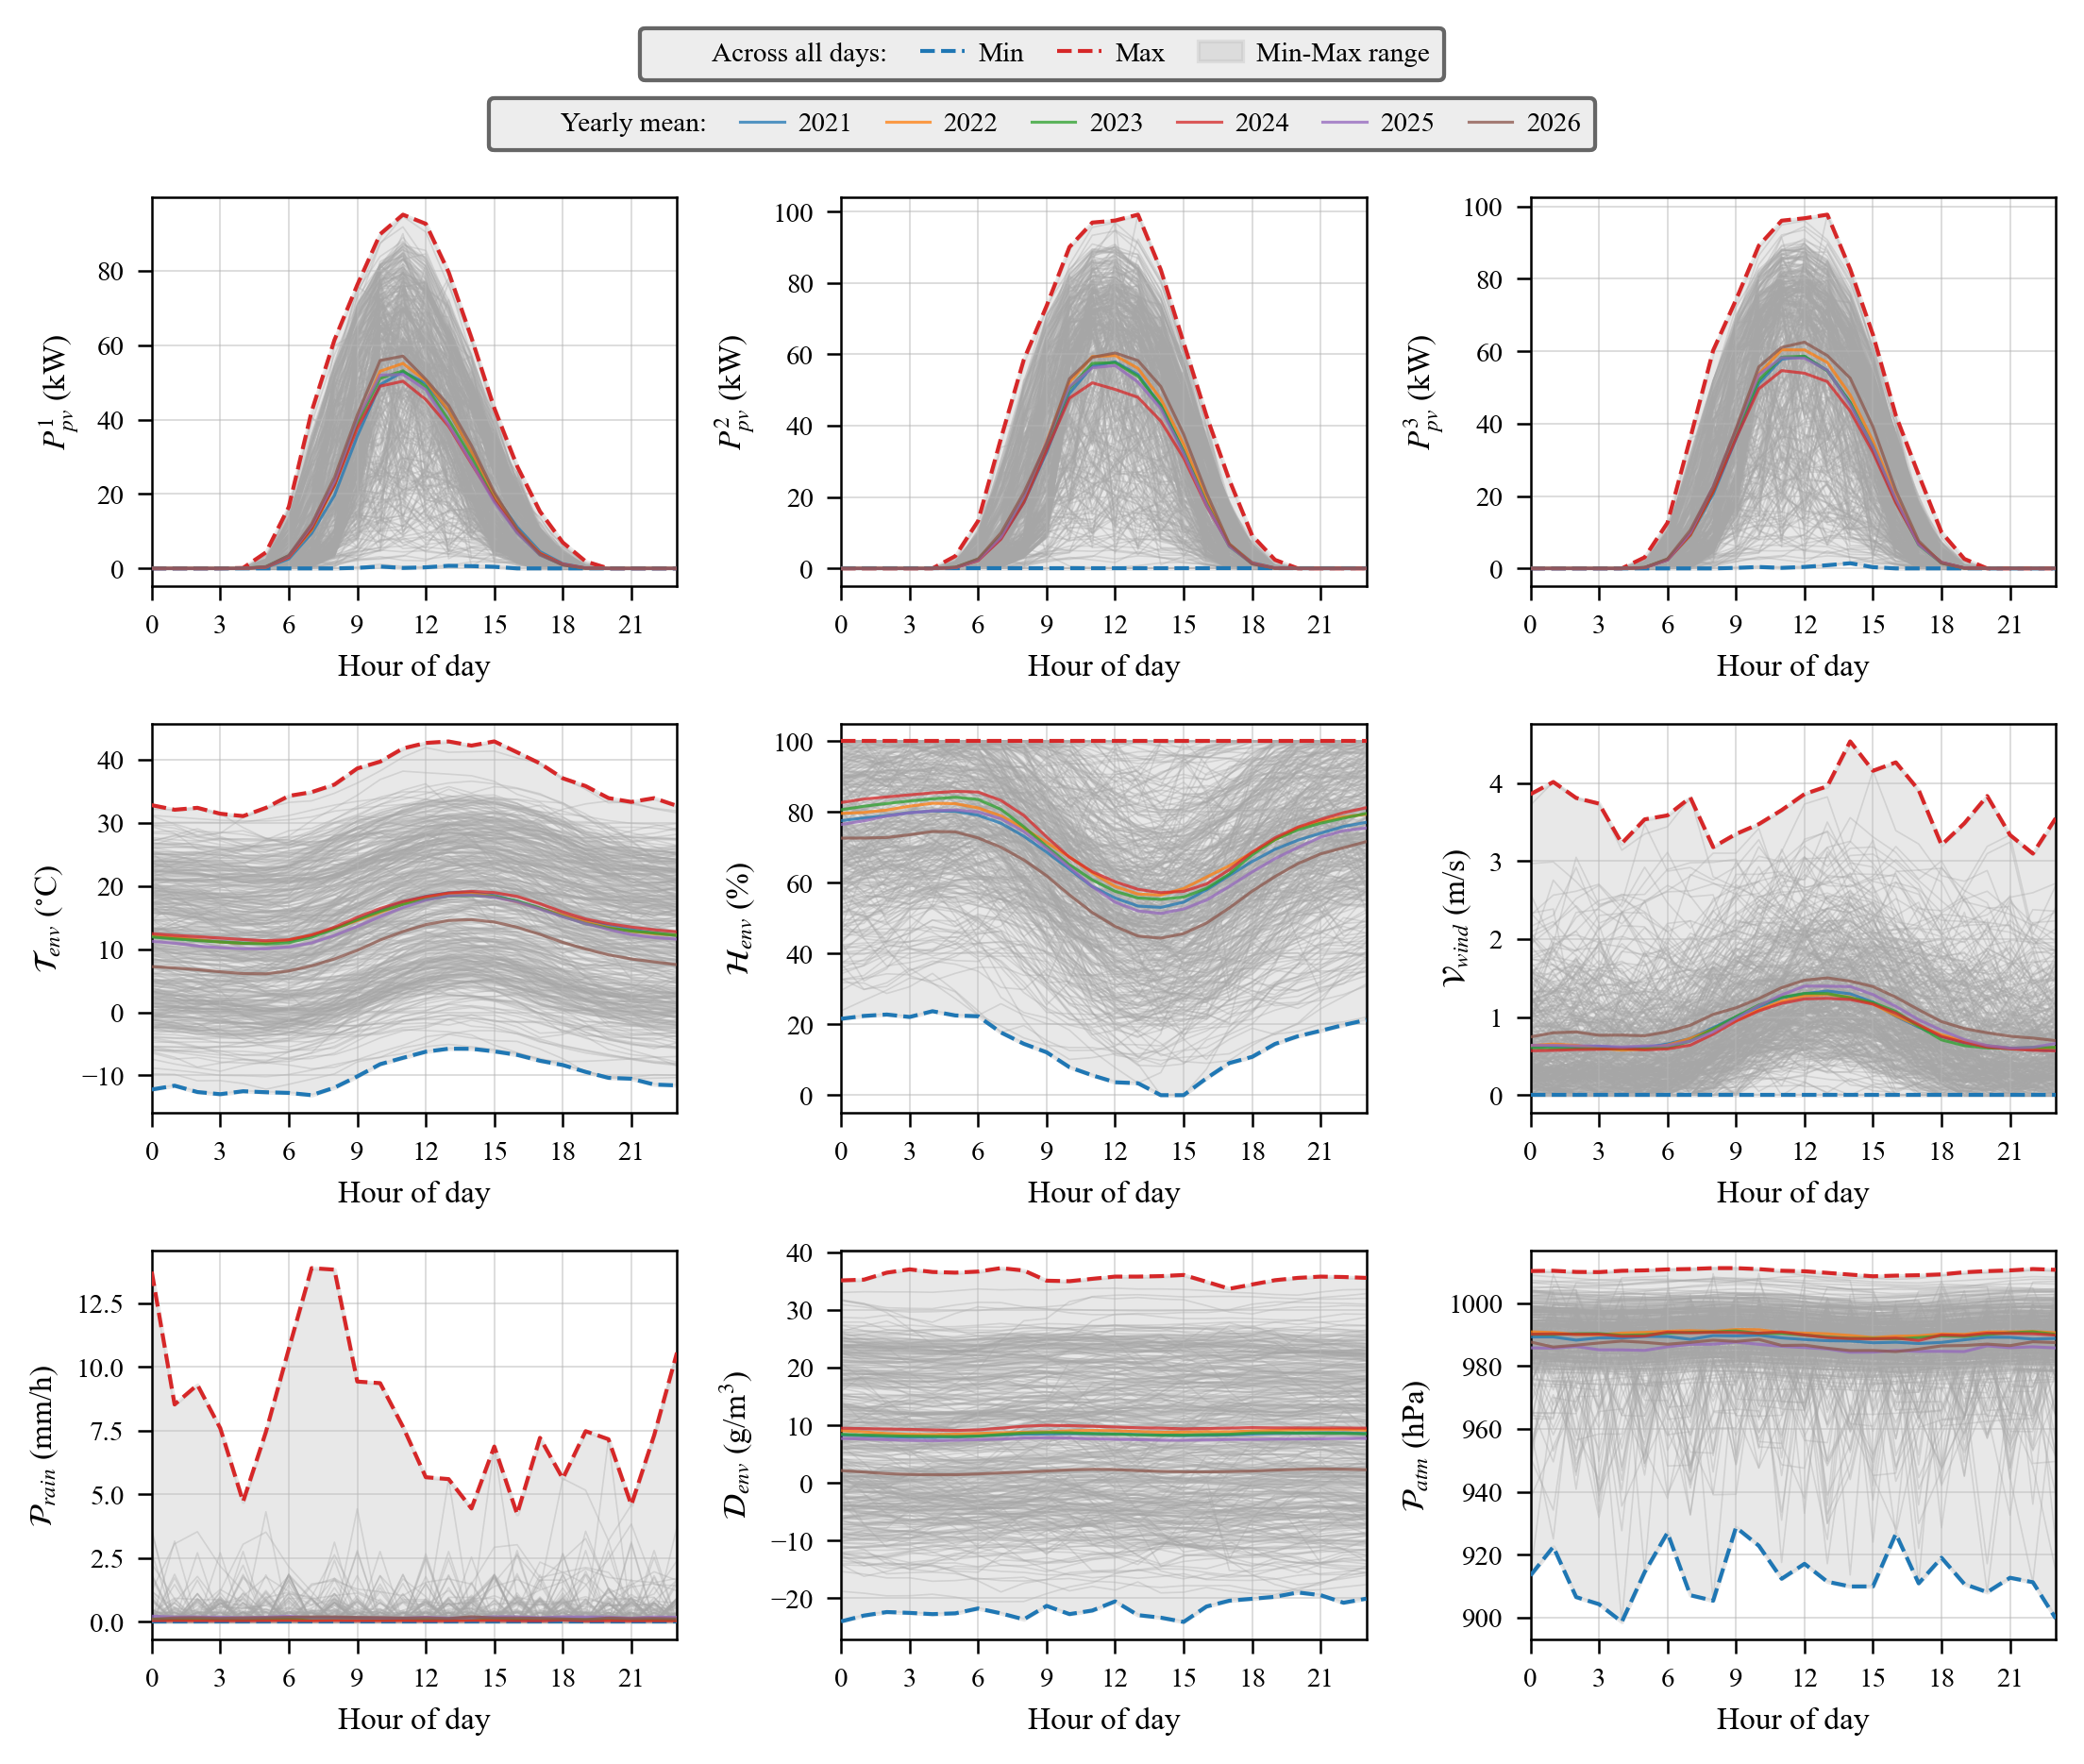

In [34]:
import sys, os
sys.path.append(os.path.abspath('..'))   # add the IGPS project root to the path

import importlib
importlib.reload(Library.dataAnalysis)

from Library.dataAnalysis import plot_diurnal_patterns


fig = plot_diurnal_patterns(
    Site_02,
    show_individual_days=True,
    show_stats=True,
    show_years=True,
    save_fig=True,
    save_dir ='../Export/Figure/Site-02/',
    show_caption=False,  # caption text will be added in the notebook
    fig_caption ="Fig. 1: Diurnal patterns at Site 02 (2021-2026)",   # caption text
    figsize=(7.4, 6.2),
    year_alpha=0.75,          # more see-through if still too dense
    year_linewidth=0.75,
)

In [ ]:
Site_02['DT'] = pd.to_datetime(Site_02['DT'])
Site_02 = Site_02.set_index('DT').sort_index()

full = pd.date_range(Site_02.index.min(), Site_02.index.max(), freq='h')

missing = full.difference(Site_02.index)
print(f"{len(missing)} missing timestamps")
print(missing)

# add the missing rows (values become NaN), restore DT as a column
Site_02 = Site_02.reindex(full)
Site_02.index.name = 'DT'

0 missing timestamps
DatetimeIndex([], dtype='datetime64[ns]', freq='h')


In [ ]:
Site_02

,P_PV1_kW,P_PV2_kW,P_PV3_kW,T_env_C,H_env_%,V_wind_m/s,P_rain_mm/h,D_env_g/m^3,P_atm_hPa
DT,,,,,,,,,
2021-01-01 00:00:00,0.0,0.0,0.0,2.314734,72.769540,0.308865,0.0,-1.749247,975.497891
2021-01-01 01:00:00,0.0,0.0,0.0,2.701183,73.179188,0.291979,0.0,-1.635891,991.764935
2021-01-01 02:00:00,0.0,0.0,0.0,1.639976,76.282423,0.329075,0.0,-2.034857,991.659843
2021-01-01 03:00:00,0.0,0.0,0.0,1.368359,78.469538,0.275586,0.0,-1.523459,975.044409
2021-01-01 04:00:00,0.0,0.0,0.0,1.262729,77.485211,0.442839,0.0,-1.412358,958.867442
...,...,...,...,...,...,...,...,...,...
2026-06-13 20:00:00,0.0,0.0,0.0,24.182719,84.906835,0.353300,0.0,21.190415,981.690412
2026-06-13 21:00:00,0.0,0.0,0.0,23.132131,89.095099,0.216502,0.0,21.532606,982.191403
2026-06-13 22:00:00,0.0,0.0,0.0,21.452902,95.442747,0.057772,0.0,21.543306,982.884489


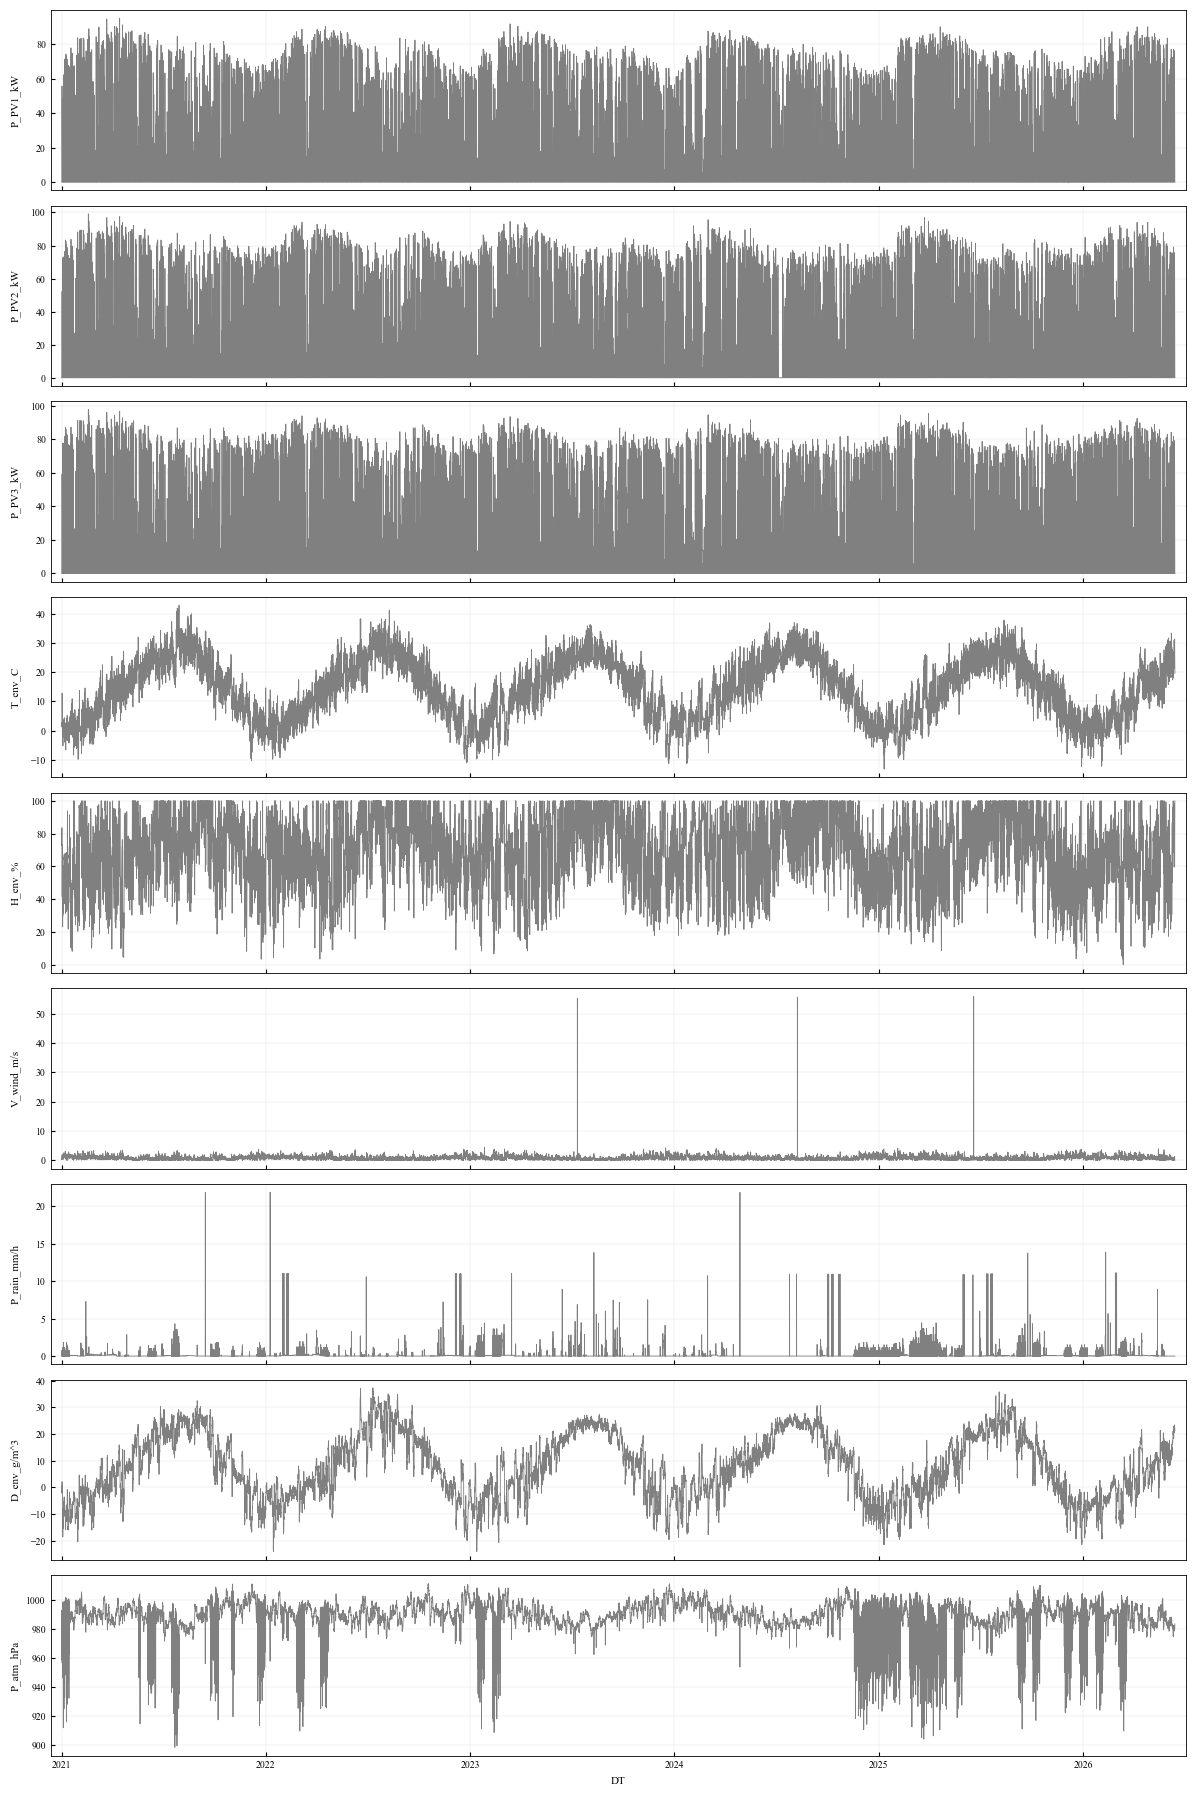

(<Figure size 1200x1800 with 9 Axes>,
 array([<Axes: ylabel='P_PV1_kW'>, <Axes: ylabel='P_PV2_kW'>,
        <Axes: ylabel='P_PV3_kW'>, <Axes: ylabel='T_env_C'>,
        <Axes: ylabel='H_env_%'>, <Axes: ylabel='V_wind_m/s'>,
        <Axes: ylabel='P_rain_mm/h'>, <Axes: ylabel='D_env_g/m^3'>,
        <Axes: xlabel='DT', ylabel='P_atm_hPa'>], dtype=object))

In [ ]:
from Library.dataProcessing import plot_selected_columns
plot_selected_columns(Site_02, Site_02.columns.tolist(), x='DT')

### <u>__Scaling__ Dataset </u>

In [ ]:
Site_02

,P_PV1_kW,P_PV2_kW,P_PV3_kW,T_env_C,H_env_%,V_wind_m/s,P_rain_mm/h,D_env_g/m^3,P_atm_hPa
DT,,,,,,,,,
2021-01-01 00:00:00,0.0,0.0,0.0,2.314734,72.769540,0.308865,0.0,-1.749247,975.497891
2021-01-01 01:00:00,0.0,0.0,0.0,2.701183,73.179188,0.291979,0.0,-1.635891,991.764935
2021-01-01 02:00:00,0.0,0.0,0.0,1.639976,76.282423,0.329075,0.0,-2.034857,991.659843
2021-01-01 03:00:00,0.0,0.0,0.0,1.368359,78.469538,0.275586,0.0,-1.523459,975.044409
2021-01-01 04:00:00,0.0,0.0,0.0,1.262729,77.485211,0.442839,0.0,-1.412358,958.867442
...,...,...,...,...,...,...,...,...,...
2026-06-13 20:00:00,0.0,0.0,0.0,24.182719,84.906835,0.353300,0.0,21.190415,981.690412
2026-06-13 21:00:00,0.0,0.0,0.0,23.132131,89.095099,0.216502,0.0,21.532606,982.191403
2026-06-13 22:00:00,0.0,0.0,0.0,21.452902,95.442747,0.057772,0.0,21.543306,982.884489


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import joblib

# ----- Scale -----
scaler = MinMaxScaler(feature_range=(0, 1))
Site_02_scaled = pd.DataFrame(
    scaler.fit_transform(Site_02),
    columns=Site_02.columns,
    index=Site_02.index
)

# ----- Save -----
joblib.dump(scaler, f"{expModelDir}scaler_Site_02.joblib")                               # the scaler (needed to reverse)
Site_02_scaled.to_csv(f"{expDataDir}Site_02_scaled.gzip", compression="gzip")            # the scaled data

# # ----- Reverse (whenever you need original values back) -----
# scaler = joblib.load("scaler_Site_02.joblib")
# Site_02_original = pd.DataFrame(
#     scaler.inverse_transform(Site_02_scaled),
#     columns=Site_02_scaled.columns,
#     index=Site_02_scaled.index
# )

In [ ]:
Site_02_scaled

,P_PV1_kW,P_PV2_kW,P_PV3_kW,T_env_C,H_env_%,V_wind_m/s,P_rain_mm/h,D_env_g/m^3,P_atm_hPa
DT,,,,,,,,,
2021-01-01 00:00:00,0.0,0.0,0.0,0.275482,0.727695,0.005523,0.0,0.364388,0.683011
2021-01-01 01:00:00,0.0,0.0,0.0,0.282381,0.731792,0.005221,0.0,0.366235,0.827657
2021-01-01 02:00:00,0.0,0.0,0.0,0.263436,0.762824,0.005885,0.0,0.359735,0.826723
2021-01-01 03:00:00,0.0,0.0,0.0,0.258587,0.784695,0.004928,0.0,0.368067,0.678978
2021-01-01 04:00:00,0.0,0.0,0.0,0.256702,0.774852,0.007919,0.0,0.369877,0.535133
...,...,...,...,...,...,...,...,...,...
2026-06-13 20:00:00,0.0,0.0,0.0,0.665870,0.849068,0.006318,0.0,0.738152,0.738075
2026-06-13 21:00:00,0.0,0.0,0.0,0.647115,0.890951,0.003871,0.0,0.743727,0.742529
2026-06-13 22:00:00,0.0,0.0,0.0,0.617138,0.954427,0.001033,0.0,0.743902,0.748692


In [ ]:
Site_02_scaled.isna().sum()

P_PV1_kW       0
P_PV2_kW       0
P_PV3_kW       0
T_env_C        0
H_env_%        0
V_wind_m/s     0
P_rain_mm/h    0
D_env_g/m^3    0
P_atm_hPa      0
dtype: int64

### <u>__Training and Testing__ Dataset </u>

In [ ]:
# Split point: train = up to and including 2026-05-31, test = from 2026-06-01 onward
split_date = "2026-05-31"

env_cols = ["T_env_C", "H_env_%", "V_wind_m/s", "P_rain_mm/h", "D_env_g/m^3", "P_atm_hPa"]

# ---------- PV1 ----------
df_pv1 = Site_02_scaled[["P_PV1_kW"] + env_cols].rename(columns={"P_PV1_kW": "P_kW"})
Site_02_PV1_Scaled_Train = df_pv1.loc[:split_date]
Site_02_PV1_Scaled_Train.to_csv(f"{expDataDir}Site_02_PV1_Scaled_Train.csv")
Site_02_PV1_Scaled_Test  = df_pv1.loc["2026-06-01":]
Site_02_PV1_Scaled_Test.to_csv(f"{expDataDir}Site_02_PV1_Scaled_Test.csv")


# ---------- PV2 ----------
df_pv2 = Site_02_scaled[["P_PV2_kW"] + env_cols].rename(columns={"P_PV2_kW": "P_kW"})
Site_02_PV2_Scaled_Train = df_pv2.loc[:split_date]
Site_02_PV2_Scaled_Train.to_csv(f"{expDataDir}Site_02_PV2_Scaled_Train.csv")
Site_02_PV2_Scaled_Test  = df_pv2.loc["2026-06-01":]
Site_02_PV2_Scaled_Test.to_csv(f"{expDataDir}Site_02_PV2_Scaled_Test.csv")

# ---------- PV3 ----------
df_pv3 = Site_02_scaled[["P_PV3_kW"] + env_cols].rename(columns={"P_PV3_kW": "P_kW"})
Site_02_PV3_Scaled_Train = df_pv3.loc[:split_date]
Site_02_PV3_Scaled_Train.to_csv(f"{expDataDir}Site_02_PV3_Scaled_Train.csv")
Site_02_PV3_Scaled_Test  = df_pv3.loc["2026-06-01":]
Site_02_PV3_Scaled_Test.to_csv(f"{expDataDir}Site_02_PV3_Scaled_Test.csv")